# Proyek Prapemrosesan Data: World Bank Global Education Statistics (EdStats)
**Mata Kuliah:** Rekayasa Data (Data Engineering)  
**Sumber Dataset:** [Kaggle - World Bank Education Statistics](https://www.kaggle.com/datasets/theworldbank/education-statistics) | [World Bank Official Data Catalog](https://datacatalog.worldbank.org/search/dataset/0038480/Education-Statistics)  
**Topik:** Pipeline Data Preprocessing Lengkap 5 Tabel dan Benchmarking Angka Partisipasi Murni (*Net Enrolment Rate*) Pendidikan Dasar Negara Anggota G20 (2000–2017)
---


## 1. Langkah 1: Impor Pustaka, Pemuatan 5 Berkas Data, dan Profiling Awal
Memuat pustaka analisis data (`pandas`, `numpy`, `scipy`, `sklearn`, `matplotlib`, `seaborn`), membaca 5 tabel dataset Bank Dunia (`EdStatsData`, `EdStatsCountry`, `EdStatsSeries`, `EdStatsFootNote`, `EdStatsCountry-Series`), dan memeriksa profil dimensi data mentah.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Pemetaan indikator pendidikan dasar
IND_NAMES = {
    'SE.PRM.NENR': 'Partisipasi Murni Total (%)',
    'SE.PRM.NENR.FE': 'Partisipasi Murni Perempuan (%)',
    'SE.PRM.NENR.MA': 'Partisipasi Murni Laki-laki (%)',
    'SE.PRM.CMPT.ZS': 'Kelulusan Pendidikan Dasar (%)',
    'SE.PRM.ENRL.TC.ZS': 'Rasio Murid per Guru',
    'SE.PRM.DROP.ZS': 'Tingkat Putus Sekolah (%)'
}

print('Pustaka siap. Versi Pandas:', pd.__version__)

Pustaka siap. Versi Pandas: 2.3.3


In [2]:
DATA_DIR = './edstats-csv-zip-32-mb-'

# Pemuatan 5 tabel dataset
df_data = pd.read_csv(os.path.join(DATA_DIR, 'EdStatsData.csv'))
df_country = pd.read_csv(os.path.join(DATA_DIR, 'EdStatsCountry.csv'))
df_series = pd.read_csv(os.path.join(DATA_DIR, 'EdStatsSeries.csv'))
df_footnote = pd.read_csv(os.path.join(DATA_DIR, 'EdStatsFootNote.csv'))
df_country_series = pd.read_csv(os.path.join(DATA_DIR, 'EdStatsCountry-Series.csv'))

print('--- Profil Dimensi 5 Tabel ---')
print(f'1. EdStatsData (Tabel Fakta Utama)       : {df_data.shape[0]:,} baris x {df_data.shape[1]} kolom')
print(f'2. EdStatsCountry (Dimensi Negara)        : {df_country.shape[0]:,} baris x {df_country.shape[1]} kolom')
print(f'3. EdStatsSeries (Dimensi Indikator)      : {df_series.shape[0]:,} baris x {df_series.shape[1]} kolom')
print(f'4. EdStatsFootNote (Log Metadata Survei)  : {df_footnote.shape[0]:,} baris x {df_footnote.shape[1]} kolom')
print(f'5. EdStatsCountry-Series (Asosiasi Lokal) : {df_country_series.shape[0]:,} baris x {df_country_series.shape[1]} kolom')

--- Profil Dimensi 5 Tabel ---
1. EdStatsData (Tabel Fakta Utama)       : 886,930 baris x 70 kolom
2. EdStatsCountry (Dimensi Negara)        : 241 baris x 32 kolom
3. EdStatsSeries (Dimensi Indikator)      : 3,665 baris x 21 kolom
4. EdStatsFootNote (Log Metadata Survei)  : 643,638 baris x 5 kolom
5. EdStatsCountry-Series (Asosiasi Lokal) : 613 baris x 4 kolom


In [3]:
# Evaluasi missing values pada tabel fakta utama
total_cells = df_data.shape[0] * df_data.shape[1]
total_missing = df_data.isnull().sum().sum()
print('--- Evaluasi Kualitas Data Mentah ---')
print(f'Total Sel              : {total_cells:,} sel')
print(f'Total Sel Kosong (NaN) : {total_missing:,} sel')
print(f'Missing Rate           : {(total_missing / total_cells) * 100:.2f}%')

--- Evaluasi Kualitas Data Mentah ---
Total Sel              : 62,085,100 sel
Total Sel Kosong (NaN) : 53,455,179 sel
Missing Rate           : 86.10%


## 2. Langkah 2: Strategi Reduksi Data Awal (Data Reduction)
Menerapkan seleksi dimensi geografis (19 Negara Berdaulat Anggota G20), seleksi fitur domain pendidikan dasar berbasis Partisipasi Murni (*Net Enrolment Rate / NER*), dan reduksi dimensi temporal kontinu (2000–2017) untuk mengeliminasi kolom proyeksi teoritis masa depan (>2017) dan artefak `Unnamed: 69`.

In [4]:
# 1. Reduksi geografis: 19 Negara Anggota G20
g20_countries = [
    'ARG', 'AUS', 'BRA', 'CAN', 'CHN', 'FRA', 'DEU', 'IND', 'IDN', 'ITA',
    'JPN', 'KOR', 'MEX', 'RUS', 'SAU', 'ZAF', 'TUR', 'GBR', 'USA'
]
df_reduced = df_data[df_data['Country Code'].isin(g20_countries)].copy()

# 2. Seleksi indikator pendidikan dasar
key_indicators = list(IND_NAMES.keys())
df_reduced = df_reduced[df_reduced['Indicator Code'].isin(key_indicators)].copy()

# 3. Reduksi rentang tahun (2000 - 2017)
year_cols = [str(y) for y in range(2000, 2018)]
id_cols = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
df_reduced = df_reduced[id_cols + year_cols].copy()

print('=== EVALUASI EFISIENSI REDUKSI DATA ===')
print(f'Dimensi Awal    : {df_data.shape[0]:,} baris x {df_data.shape[1]} kolom')
print(f'Dimensi Akhir   : {df_reduced.shape[0]:,} baris x {df_reduced.shape[1]} kolom')
print(f'Pengurangan Baris: {(1 - df_reduced.shape[0]/df_data.shape[0])*100:.2f}%')
print(f'Pengurangan Kolom: {(1 - df_reduced.shape[1]/df_data.shape[1])*100:.2f}%')

mem_before = df_data.memory_usage(deep=True).sum() / (1024 * 1024)
mem_after = df_reduced.memory_usage(deep=True).sum() / (1024 * 1024)
print(f'Alokasi Memori  : {mem_before:.2f} MB -> {mem_after:.2f} MB')

# Sampel data tereduksi
sample_preview = df_reduced[df_reduced['Country Code'].isin(['IDN', 'USA', 'JPN']) & (df_reduced['Indicator Code'] == 'SE.PRM.NENR')]
display(sample_preview[['Country Name', 'Country Code', 'Indicator Name', '2000', '2005', '2010', '2015']])

=== EVALUASI EFISIENSI REDUKSI DATA ===
Dimensi Awal    : 886,930 baris x 70 kolom
Dimensi Akhir   : 114 baris x 22 kolom
Pengurangan Baris: 99.99%
Pengurangan Kolom: 68.57%


Alokasi Memori  : 706.25 MB -> 0.05 MB


,Country Name,Country Code,Indicator Name,2000,2005,2010,2015
419460,Indonesia,IDN,"Net enrolment rate, primary, both sexes (%)",NaN,88.80,93.80,89.74
448780,Japan,JPN,"Net enrolment rate, primary, both sexes (%)",99.97,100.00,99.94,NaN
848265,United States,USA,"Net enrolment rate, primary, both sexes (%)",96.70,93.69,93.62,93.75


## 3. Langkah 3: Integrasi 5 Tabel & Resolusi Konflik Skema/Representasi Nilai (Data Integration)
Menggabungkan tabel fakta dengan 4 tabel dimensi (`EdStatsCountry`, `EdStatsSeries`, `EdStatsFootNote`, `EdStatsCountry-Series`), mengatasi **konflik skema** (penamaan kunci berbeda) dan **konflik representasi data** (konversi `YR2000` ke integer `2000`), serta melakukan **Uji Chi-Square $\chi^2$** untuk deteksi redundansi.

In [5]:
# 1. Integrasi dimensi negara (EdStatsCountry)
country_cols = ['Country Code', 'Region', 'Income Group', 'Lending category']
df_integrated = pd.merge(
    df_reduced,
    df_country[country_cols],
    on='Country Code',
    how='left',
    validate='m:1'
)

# 2. Integrasi dimensi indikator (EdStatsSeries)
df_integrated = pd.merge(
    df_integrated,
    df_series[['Series Code', 'Topic', 'Unit of measure']],
    left_on='Indicator Code',
    right_on='Series Code',
    how='left',
    validate='m:1'
).drop(columns=['Series Code'])

# 3. Restrukturisasi format long
meta_cols = ['Country Code', 'Country Name', 'Region', 'Income Group', 'Lending category', 'Indicator Code', 'Topic']
df_long = pd.melt(df_integrated, id_vars=meta_cols, value_vars=year_cols, var_name='Year', value_name='Value')
df_long['Year'] = df_long['Year'].astype(int)

# 4. Integrasi log metadata survei (EdStatsFootNote) & pembersihan format tahun
df_fn_clean = df_footnote.dropna(subset=['CountryCode', 'SeriesCode', 'Year']).copy()
df_fn_clean['Year_Clean'] = df_fn_clean['Year'].astype(str).str.replace('YR', '', regex=False)
df_fn_clean = df_fn_clean[df_fn_clean['Year_Clean'].str.isnumeric()]
df_fn_clean['Year'] = df_fn_clean['Year_Clean'].astype(int)

# Ekstraksi atribut provenance
df_fn_g20 = df_fn_clean[df_fn_clean['CountryCode'].isin(g20_countries) & df_fn_clean['SeriesCode'].isin(key_indicators) & df_fn_clean['Year'].isin(range(2000, 2018))].copy()
df_fn_g20['Is_Estimated'] = df_fn_g20['DESCRIPTION'].str.contains('estimat|uis', case=False, na=False)

df_long_fn = pd.merge(
    df_long,
    df_fn_g20[['CountryCode', 'SeriesCode', 'Year', 'Is_Estimated']].drop_duplicates(),
    left_on=['Country Code', 'Indicator Code', 'Year'],
    right_on=['CountryCode', 'SeriesCode', 'Year'],
    how='left'
).drop(columns=['CountryCode', 'SeriesCode'])
df_long_fn['Is_Estimated'] = df_long_fn['Is_Estimated'].fillna(False)

# 5. Integrasi catatan negara-indikator (EdStatsCountry-Series)
df_cs_clean = df_country_series.dropna(subset=['CountryCode', 'SeriesCode']).copy()
df_cs_clean['Has_Country_Series_Note'] = True
df_long_all = pd.merge(
    df_long_fn,
    df_cs_clean[['CountryCode', 'SeriesCode', 'Has_Country_Series_Note']].drop_duplicates(),
    left_on=['Country Code', 'Indicator Code'],
    right_on=['CountryCode', 'SeriesCode'],
    how='left'
).drop(columns=['CountryCode', 'SeriesCode'])
df_long_all['Has_Country_Series_Note'] = df_long_all['Has_Country_Series_Note'].fillna(False)

print('=== HASIL INTEGRASI 5 TABEL ===')
print(f'Total Baris Terintegrasi: {df_long_all.shape[0]:,} baris')
print('\nSebaran Status Estimasi (Is_Estimated):')
print(df_long_all['Is_Estimated'].value_counts())

# Sampel integrasi 2015
sample_int = df_long_all[df_long_all['Country Code'].isin(['IDN', 'USA', 'DEU', 'IND']) & (df_long_all['Year'] == 2015) & (df_long_all['Indicator Code'] == 'SE.PRM.NENR')]
display(sample_int[['Country Name', 'Year', 'Region', 'Income Group', 'Indicator Code', 'Value', 'Is_Estimated']])

=== HASIL INTEGRASI 5 TABEL ===
Total Baris Terintegrasi: 2,052 baris

Sebaran Status Estimasi (Is_Estimated):
Is_Estimated
False    1336
True      716
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1388\4087955408.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long_fn['Is_Estimated'] = df_long_fn['Is_Estimated'].fillna(False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_1388\4087955408.py:55: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long_all['Has_Country_Series_Note'] = df_long_all['Has_Country_Series_Note'].fillna(False)


,Country Name,Year,Region,Income Group,Indicator Code,Value,Is_Estimated
1747,Germany,2015,Europe & Central Asia,High income: OECD,SE.PRM.NENR,98.68,True
1753,India,2015,South Asia,Lower middle income,SE.PRM.NENR,NaN,False
1759,Indonesia,2015,East Asia & Pacific,Lower middle income,SE.PRM.NENR,89.74,True
1819,United States,2015,North America,High income: OECD,SE.PRM.NENR,93.75,False


In [6]:
# Uji Chi-Square untuk dependensi Income Group vs Region
contingency_tbl = pd.crosstab(df_integrated['Income Group'], df_integrated['Region'])
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_tbl)

print('=== ANALISIS REDUNDANSI (CHI-SQUARE TEST) ===')
print(f'Chi-Square Statistic (χ²): {chi2_stat:.4f}')
print(f'Degrees of Freedom (df)  : {dof}')
print(f'p-value                  : {p_val:.4e}')
if p_val < 0.05:
    print('Kesimpulan: Terdapat asosiasi dependensi signifikan antara Income Group dan Region (p < 0.05).')
display(contingency_tbl)

=== ANALISIS REDUNDANSI (CHI-SQUARE TEST) ===
Chi-Square Statistic (χ²): 185.7778
Degrees of Freedom (df)  : 18
p-value                  : 6.8502e-30
Kesimpulan: Terdapat asosiasi dependensi signifikan antara Income Group dan Region (p < 0.05).


Region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
Income Group,,,,,,,
High income: OECD,18,24,0,0,12,0,0
High income: nonOECD,0,6,0,6,0,0,0
Lower middle income,6,0,0,0,0,6,0
Upper middle income,6,6,18,0,0,0,6


## 4. Langkah 4: Pembersihan Data (Data Cleaning) & Transformasi Tidy Panel
Melakukan pivoting ke format panel fitur (*Country-Year*), imputasi bertingkat 3-Tier (*interpolasi temporal, median kelompok pendapatan, median global*), deteksi outlier via IQR & Boxplot, serta ekspor dataset bersih.

In [7]:
# 1. Pivoting ke format panel (19 Negara x 18 Tahun = 342 Baris)
df_panel = df_long_all.pivot(
    index=['Country Code', 'Country Name', 'Region', 'Income Group', 'Lending category', 'Year'],
    columns='Indicator Code',
    values='Value'
).reset_index()
df_panel.columns.name = None

print('Dimensi Format Panel Sebelum Imputasi:', df_panel.shape)
print('\nMissing Values Sebelum Imputasi:')
missing_summary = df_panel[key_indicators].isnull().sum().rename(index=IND_NAMES)
print(missing_summary)
missing_panel_raw_rate = (df_panel[key_indicators].isnull().sum().sum() / (df_panel.shape[0] * len(key_indicators))) * 100
print(f'\nMissing Rate Panel Sebelum Imputasi: {missing_panel_raw_rate:.2f}%')

# 2. Imputasi bertingkat (3-Tier Imputation)
df_clean = df_panel.sort_values(by=['Country Code', 'Year']).copy()

# Tingkat 1: Interpolasi linier temporal per negara
for ind in key_indicators:
    df_clean[ind] = df_clean.groupby('Country Code')[ind].transform(
        lambda g: g.interpolate(method='linear', limit_direction='both')
    )

# Tingkat 2: Median per kelompok pendapatan (Income Group)
for ind in key_indicators:
    df_clean[ind] = df_clean.groupby('Income Group')[ind].transform(
        lambda g: g.fillna(g.median())
    )

# Tingkat 3: Median global G20 (fallback)
for ind in key_indicators:
    df_clean[ind] = df_clean[ind].fillna(df_clean[ind].median())

print('\nMissing Values Setelah Imputasi (Lengkap 100%):')
print(df_clean[key_indicators].isnull().sum().rename(index=IND_NAMES))
print(f'\nJumlah Baris Duplikat: {df_clean.duplicated().sum()}')

Dimensi Format Panel Sebelum Imputasi: (342, 12)

Missing Values Sebelum Imputasi:
Partisipasi Murni Total (%)        113
Partisipasi Murni Perempuan (%)    156
Partisipasi Murni Laki-laki (%)    156
Kelulusan Pendidikan Dasar (%)     179
Rasio Murid per Guru               128
Tingkat Putus Sekolah (%)          223
dtype: int64

Missing Rate Panel Sebelum Imputasi: 46.54%

Missing Values Setelah Imputasi (Lengkap 100%):
Partisipasi Murni Total (%)        0
Partisipasi Murni Perempuan (%)    0
Partisipasi Murni Laki-laki (%)    0
Kelulusan Pendidikan Dasar (%)     0
Rasio Murid per Guru               0
Tingkat Putus Sekolah (%)          0
dtype: int64

Jumlah Baris Duplikat: 0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1388\3882258776.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted_ind, x='Indikator', y='Nilai', palette='Set2')


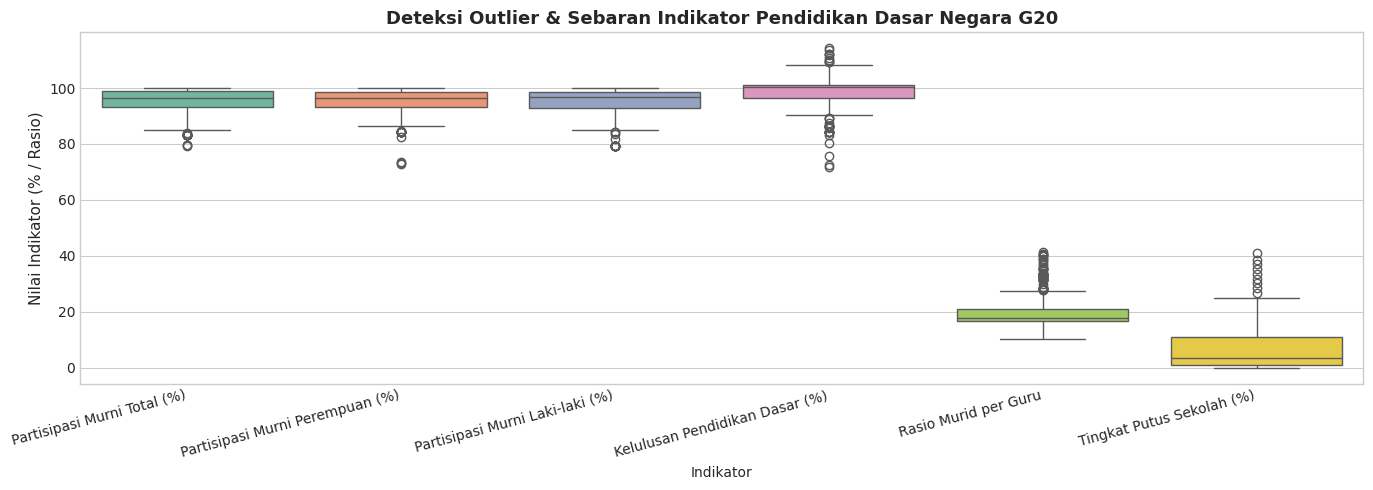

=== STATISTIK DESKRIPTIF DATASET BERSIH ===


,Partisipasi Murni Total (%),Partisipasi Murni Perempuan (%),Partisipasi Murni Laki-laki (%),Kelulusan Pendidikan Dasar (%),Rasio Murid per Guru,Tingkat Putus Sekolah (%)
count,342.00,342.00,342.00,342.00,342.00,342.00
mean,95.21,95.26,95.08,98.47,19.75,6.93
std,4.67,4.49,5.04,5.73,6.80,8.41
min,79.23,72.76,79.24,71.75,10.33,0.02
25%,93.23,93.14,92.97,96.38,16.52,0.80
50%,96.47,96.49,96.64,100.27,17.72,3.40
75%,98.81,98.52,98.64,101.14,20.92,10.83
max,100.00,99.99,99.95,114.20,41.33,40.99



Dataset bersih diekspor ke: EdStats_Cleaned_G20_2000_2017.csv


In [8]:
# 3. Deteksi Outlier & Boxplot Sebaran Indikator
plt.figure(figsize=(14, 5))
df_clean_renamed = df_clean.rename(columns=IND_NAMES)
ind_indonesian_cols = list(IND_NAMES.values())

df_melted_ind = pd.melt(df_clean_renamed, id_vars=['Country Name', 'Year'], value_vars=ind_indonesian_cols, var_name='Indikator', value_name='Nilai')

sns.boxplot(data=df_melted_ind, x='Indikator', y='Nilai', palette='Set2')
plt.title('Deteksi Outlier & Sebaran Indikator Pendidikan Dasar Negara G20', fontsize=13, fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.ylabel('Nilai Indikator (% / Rasio)', fontsize=11)
plt.tight_layout()
plt.savefig('boxplot_outlier_detection.png', dpi=300)
plt.show()

print('=== STATISTIK DESKRIPTIF DATASET BERSIH ===')
display(df_clean_renamed[ind_indonesian_cols].describe().round(2))

# Ekspor dataset bersih ke CSV
OUTPUT_CSV = 'EdStats_Cleaned_G20_2000_2017.csv'
df_clean.to_csv(OUTPUT_CSV, index=False)
print(f'\nDataset bersih diekspor ke: {OUTPUT_CSV}')

## 5. Langkah 5: Analisis Kovariansi, Korelasi Pearson, & Reduksi Dimensi dengan PCA
Menerapkan konsep dari slide materi *P05 Data Preprocessing*: Memetakan matriks korelasi/kovariansi fitur, melakukan standarisasi Z-Score ($Z = \frac{X - \mu}{\sigma}$), menghitung *Eigenvalues* & *Eigenvectors*, serta mereduksi 6 dimensi indikator menjadi 2 komponen utama (*Principal Components*) dengan visualisasi sebaran (*PCA 2D Projection*).

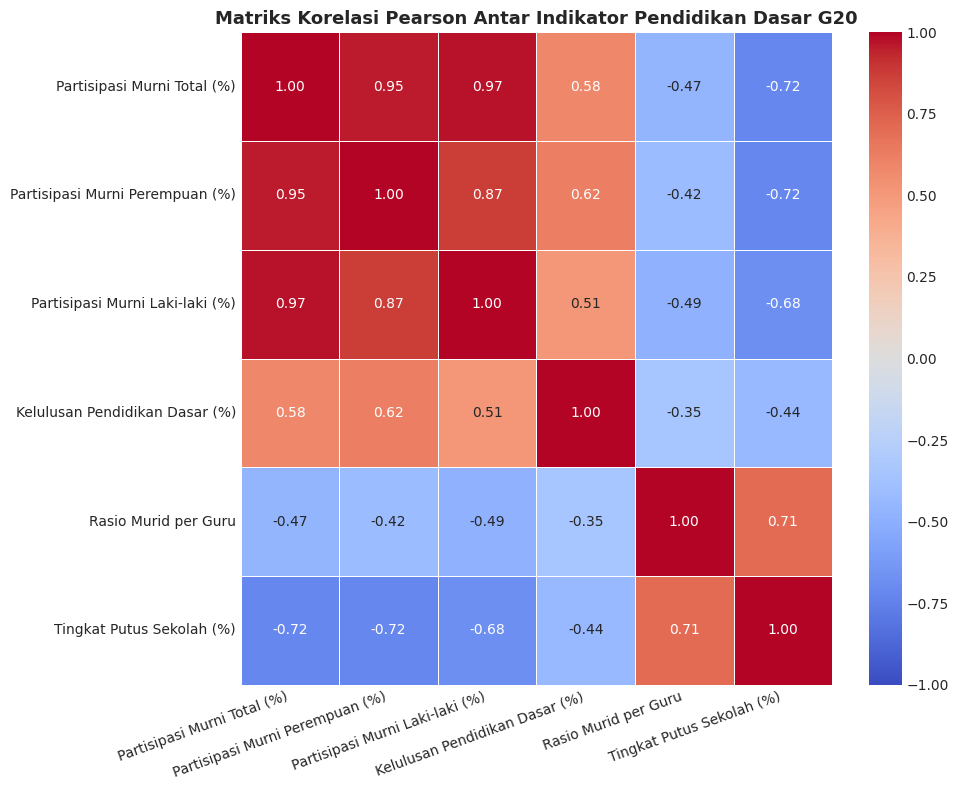

Matriks Kovariansi Numerik:


,Partisipasi Murni Total (%),Partisipasi Murni Perempuan (%),Partisipasi Murni Laki-laki (%),Kelulusan Pendidikan Dasar (%),Rasio Murid per Guru,Tingkat Putus Sekolah (%)
Partisipasi Murni Total (%),21.81,19.99,22.83,15.51,-14.85,-28.38
Partisipasi Murni Perempuan (%),19.99,20.12,19.66,15.93,-12.82,-27.33
Partisipasi Murni Laki-laki (%),22.83,19.66,25.44,14.69,-16.69,-29.03
Kelulusan Pendidikan Dasar (%),15.51,15.93,14.69,32.79,-13.66,-20.97
Rasio Murid per Guru,-14.85,-12.82,-16.69,-13.66,46.19,40.56
Tingkat Putus Sekolah (%),-28.38,-27.33,-29.03,-20.97,40.56,70.71


In [9]:
# 1. Matriks Korelasi & Kovariansi
corr_mat = df_clean_renamed[ind_indonesian_cols].corr()
cov_mat = df_clean_renamed[ind_indonesian_cols].cov()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, annot_kws={'size': 10})
plt.title('Matriks Korelasi Pearson Antar Indikator Pendidikan Dasar G20', fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

print('Matriks Kovariansi Numerik:')
display(cov_mat.round(2))

=== HASIL PRINCIPAL COMPONENT ANALYSIS (PCA) ===
Explained Variance Ratio PC1: 70.71%
Explained Variance Ratio PC2: 13.76%
Total Retensi Variansi (2 PC): 84.47%


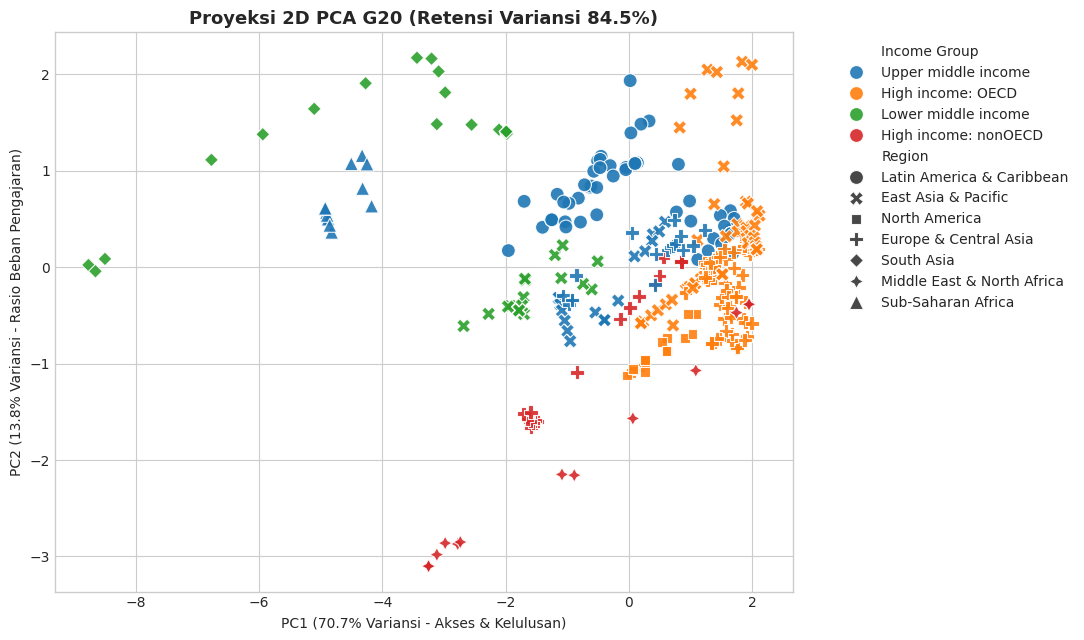

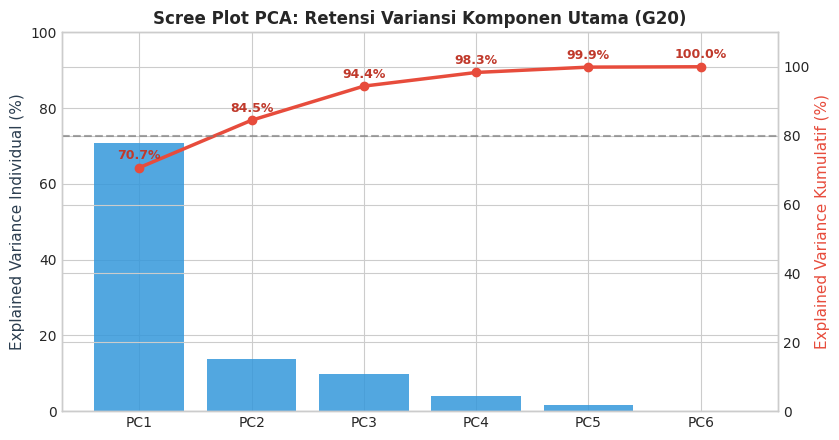

In [10]:
# 2. Standarisasi Z-Score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[key_indicators])

# 3. Ekstraksi 2 Komponen Utama (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]

evr = pca.explained_variance_ratio_
print('=== HASIL PRINCIPAL COMPONENT ANALYSIS (PCA) ===')
print(f'Explained Variance Ratio PC1: {evr[0]*100:.2f}%')
print(f'Explained Variance Ratio PC2: {evr[1]*100:.2f}%')
print(f'Total Retensi Variansi (2 PC): {sum(evr)*100:.2f}%')

# 4. Visualisasi Proyeksi 2D PCA
plt.figure(figsize=(11, 6.5))
sns.scatterplot(
    data=df_clean,
    x='PC1',
    y='PC2',
    hue='Income Group',
    style='Region',
    s=100,
    alpha=0.9
)
plt.title(f'Proyeksi 2D PCA G20 (Retensi Variansi {sum(evr)*100:.1f}%)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({evr[0]*100:.1f}% Variansi - Akses & Kelulusan)')
plt.ylabel(f'PC2 ({evr[1]*100:.1f}% Variansi - Rasio Beban Pengajaran)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_2d_projection.png', dpi=300)
plt.show()

# 5. Scree Plot Variansi PCA
pca_all = PCA().fit(X_scaled)
fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
pc_names = [f'PC{i+1}' for i in range(len(pca_all.explained_variance_ratio_))]
indiv_var = pca_all.explained_variance_ratio_ * 100
cum_var = np.cumsum(indiv_var)

ax1.bar(pc_names, indiv_var, color='#3498db', alpha=0.85, label='Variansi Individual (%)')
ax1.set_ylabel('Explained Variance Individual (%)', color='#2c3e50', fontsize=11)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.plot(pc_names, cum_var, color='#e74c3c', marker='o', linewidth=2.5, label='Variansi Kumulatif (%)')
ax2.set_ylabel('Explained Variance Kumulatif (%)', color='#e74c3c', fontsize=11)
ax2.set_ylim(0, 110)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='Threshold 80%')

for i, txt in enumerate(cum_var):
    ax2.annotate(f'{txt:.1f}%', (pc_names[i], txt + 2.5), ha='center', fontsize=9, fontweight='bold', color='#c0392b')

plt.title('Scree Plot PCA: Retensi Variansi Komponen Utama (G20)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=300)
plt.show()

## 6. Langkah 6: Diskretisasi Data & Transformasi Konsep Hierarki
Menerapkan teknik diskretisasi berbasis *Interval Binning* pada dua indikator kunci: **Kelulusan Pendidikan Dasar** (`<96%`, `96-99%`, `>99%`) dan **Rasio Murid per Guru** (`<15`, `15-20`, `>20`) untuk membentuk konsep hierarki kategorikal yang komprehensif.

In [11]:
# 1. Diskretisasi Tingkat Kelulusan Pendidikan Dasar
labels_kelulusan = ['Kelulusan Rendah (<96%)', 'Kelulusan Sedang (96-99%)', 'Kelulusan Tinggi (>99%)']
df_clean['Kategori_Kelulusan'] = pd.cut(df_clean['SE.PRM.CMPT.ZS'], bins=[0, 96, 99, 150], labels=labels_kelulusan)

# 2. Diskretisasi Rasio Murid per Guru
labels_guru = ['Rasio Ideal (<15)', 'Rasio Moderat (15-20)', 'Rasio Padat (>20)']
df_clean['Kategori_Rasio_Guru'] = pd.cut(df_clean['SE.PRM.ENRL.TC.ZS'], bins=[0, 15, 20, 100], labels=labels_guru)

print('=== DISTRIBUSI KATEGORI KELULUSAN PENDIDIKAN DASAR ===')
print(df_clean['Kategori_Kelulusan'].value_counts())
print('\n=== DISTRIBUSI KATEGORI RASIO MURID PER GURU ===')
print(df_clean['Kategori_Rasio_Guru'].value_counts())

# Sampel perbandingan kategori (Tahun 2015)
benchmark_sample = df_clean[
    (df_clean['Country Code'].isin(['IDN', 'USA', 'JPN', 'DEU', 'IND', 'BRA', 'GBR', 'CHN'])) & 
    (df_clean['Year'] == 2015)
].rename(columns=IND_NAMES)

display(benchmark_sample[['Country Name', 'Year', 'Income Group', 'Partisipasi Murni Total (%)', 'Kelulusan Pendidikan Dasar (%)', 'Kategori_Kelulusan', 'Rasio Murid per Guru', 'Kategori_Rasio_Guru']])

=== DISTRIBUSI KATEGORI KELULUSAN PENDIDIKAN DASAR ===
Kategori_Kelulusan
Kelulusan Tinggi (>99%)      185
Kelulusan Rendah (<96%)       83
Kelulusan Sedang (96-99%)     74
Name: count, dtype: int64

=== DISTRIBUSI KATEGORI RASIO MURID PER GURU ===
Kategori_Rasio_Guru
Rasio Moderat (15-20)    161
Rasio Padat (>20)        112
Rasio Ideal (<15)         69
Name: count, dtype: int64


,Country Name,Year,Income Group,Partisipasi Murni Total (%),Kelulusan Pendidikan Dasar (%),Kategori_Kelulusan,Rasio Murid per Guru,Kategori_Rasio_Guru
51,Brazil,2015,Upper middle income,92.70,100.68,Kelulusan Tinggi (>99%),20.92,Rasio Padat (>20)
87,China,2015,Upper middle income,95.06,92.47,Kelulusan Rendah (<96%),16.29,Rasio Moderat (15-20)
105,Germany,2015,High income: OECD,98.68,102.58,Kelulusan Tinggi (>99%),12.22,Rasio Ideal (<15)
141,United Kingdom,2015,High income: OECD,99.85,100.62,Kelulusan Tinggi (>99%),17.39,Rasio Moderat (15-20)
159,Indonesia,2015,Lower middle income,89.74,102.00,Kelulusan Tinggi (>99%),16.56,Rasio Moderat (15-20)
177,India,2015,Lower middle income,92.26,97.55,Kelulusan Sedang (96-99%),31.49,Rasio Padat (>20)
213,Japan,2015,High income: OECD,99.95,102.06,Kelulusan Tinggi (>99%),16.45,Rasio Moderat (15-20)
321,United States,2015,High income: OECD,93.75,100.62,Kelulusan Tinggi (>99%),14.54,Rasio Ideal (<15)


## 7. Langkah 7: Visualisasi Hasil Prapemrosesan & Analisis Tren
Bagian ini dibagi menjadi dua fokus analitis utama:
1. **Evaluasi Kualitas Sebelum vs. Sesudah Prapemrosesan (*Before vs. After Evaluation*)**: Memvalidasi penurunan missing values, efisiensi memori, dan studi kasus rekonstruksi data deret waktu.
2. **Analisis Tren & Wawasan Kebijakan Pendidikan G20 (*Trends & Insights*)**: Memetakan dinamika 19 negara G20, peta panas makro, dan paritas gender.

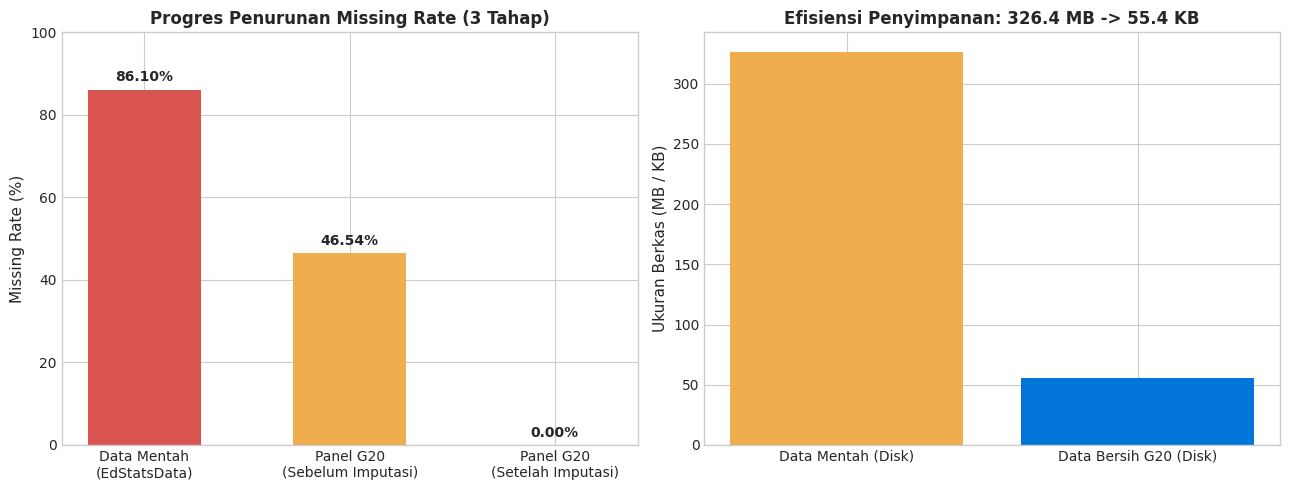

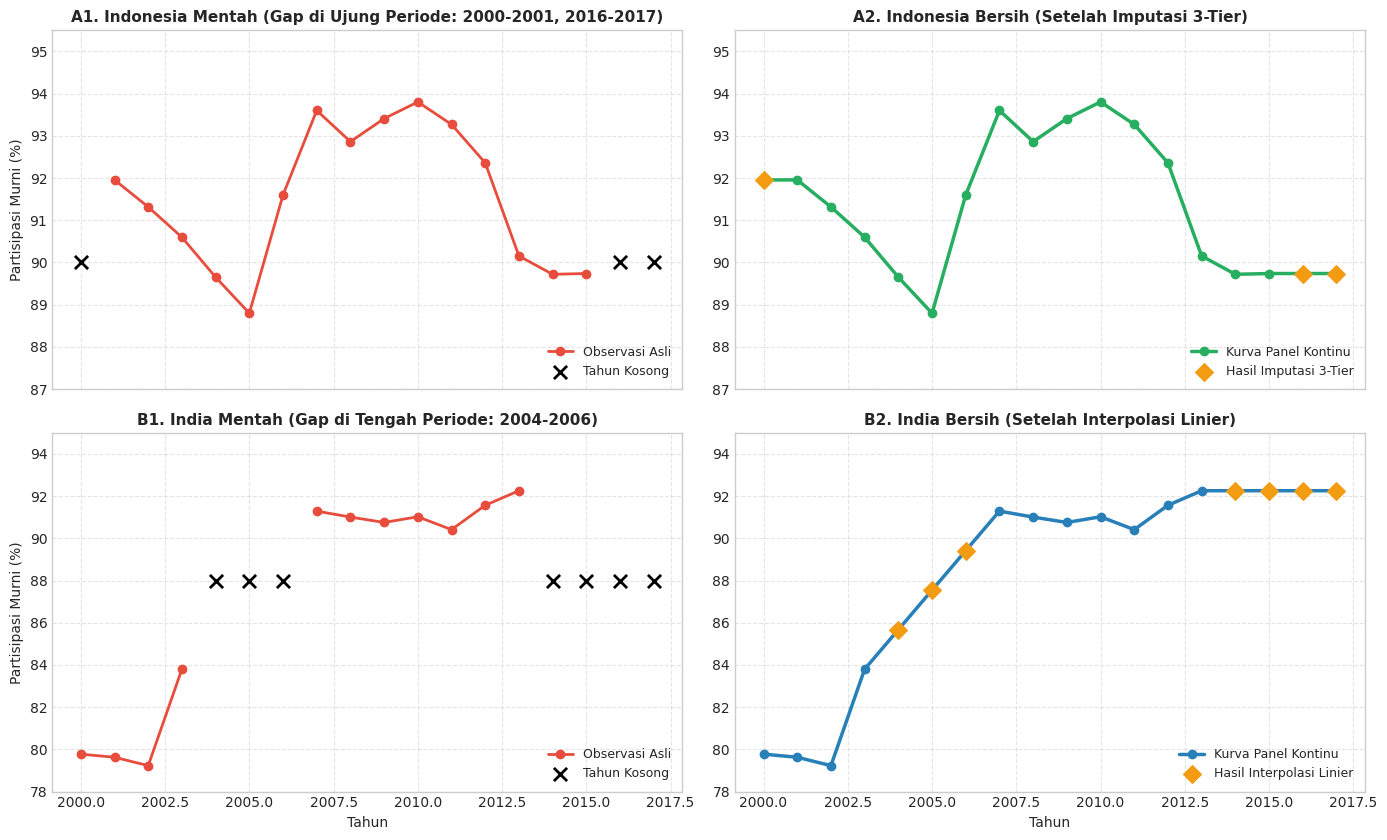

In [12]:
# 7.1 EVALUASI SEBELUM VS. SESUDAH PRAPEMROSESAN

# 1. Perbandingan Missing Rate 3 Tahap & Efisiensi Ukuran Berkas
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
stages = ['Data Mentah\n(EdStatsData)', 'Panel G20\n(Sebelum Imputasi)', 'Panel G20\n(Setelah Imputasi)']
missing_rates = [(total_missing / total_cells) * 100, missing_panel_raw_rate, 0.0]
colors = ['#d9534f', '#f0ad4e', '#5cb85c']

ax[0].bar(stages, missing_rates, color=colors, width=0.55)
ax[0].set_ylabel('Missing Rate (%)', fontsize=11)
ax[0].set_title('Progres Penurunan Missing Rate (3 Tahap)', fontweight='bold')
ax[0].set_ylim(0, 100)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 2), ha='center', fontweight='bold')

ax[1].bar(['Data Mentah (Disk)', 'Data Bersih G20 (Disk)'], [326.4, os.path.getsize(OUTPUT_CSV)/1024], color=['#f0ad4e', '#0275d8'])
ax[1].set_ylabel('Ukuran Berkas (MB / KB)', fontsize=11)
ax[1].set_title(f'Efisiensi Penyimpanan: 326.4 MB -> {os.path.getsize(OUTPUT_CSV)/1024:.1f} KB', fontweight='bold')

plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=300)
plt.show()

# 2. Studi Kasus Imputasi Deret Waktu: Indonesia (Ujung Gap) & India (Tengah Gap)
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharex=True)
years = list(range(2000, 2018))

# Studi Kasus: Indonesia
idn_raw = df_panel[df_panel['Country Code'] == 'IDN'].sort_values('Year')['SE.PRM.NENR'].values
idn_clean = df_clean[df_clean['Country Code'] == 'IDN'].sort_values('Year')['SE.PRM.NENR'].values
mask_idn = np.isnan(idn_raw)
years_idn_miss = np.array(years)[mask_idn]

axes[0, 0].plot(years, idn_raw, marker='o', color='#e74c3c', linewidth=2, label='Observasi Asli')
axes[0, 0].scatter(years_idn_miss, [90.0]*len(years_idn_miss), marker='x', color='black', s=90, linewidth=2, label='Tahun Kosong', zorder=5)
axes[0, 0].set_title('A1. Indonesia Mentah (Gap di Ujung Periode: 2000-2001, 2016-2017)', fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('Partisipasi Murni (%)', fontsize=10)
axes[0, 0].set_ylim(87, 95.5)
axes[0, 0].legend(loc='lower right', fontsize=9)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].plot(years, idn_clean, marker='o', color='#27ae60', linewidth=2.5, label='Kurva Panel Kontinu')
axes[0, 1].scatter(years_idn_miss, idn_clean[mask_idn], marker='D', color='#f39c12', s=80, label='Hasil Imputasi 3-Tier', zorder=5)
axes[0, 1].set_title('A2. Indonesia Bersih (Setelah Imputasi 3-Tier)', fontweight='bold', fontsize=11)
axes[0, 1].set_ylim(87, 95.5)
axes[0, 1].legend(loc='lower right', fontsize=9)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Studi Kasus: India
ind_raw = df_panel[df_panel['Country Code'] == 'IND'].sort_values('Year')['SE.PRM.NENR'].values
ind_clean = df_clean[df_clean['Country Code'] == 'IND'].sort_values('Year')['SE.PRM.NENR'].values
mask_ind = np.isnan(ind_raw)
years_ind_miss = np.array(years)[mask_ind]

axes[1, 0].plot(years, ind_raw, marker='o', color='#e74c3c', linewidth=2, label='Observasi Asli')
axes[1, 0].scatter(years_ind_miss, [88.0]*len(years_ind_miss), marker='x', color='black', s=90, linewidth=2, label='Tahun Kosong', zorder=5)
axes[1, 0].set_title('B1. India Mentah (Gap di Tengah Periode: 2004-2006)', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Tahun', fontsize=10)
axes[1, 0].set_ylabel('Partisipasi Murni (%)', fontsize=10)
axes[1, 0].set_ylim(78, 95)
axes[1, 0].legend(loc='lower right', fontsize=9)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].plot(years, ind_clean, marker='o', color='#2980b9', linewidth=2.5, label='Kurva Panel Kontinu')
axes[1, 1].scatter(years_ind_miss, ind_clean[mask_ind], marker='D', color='#f39c12', s=80, label='Hasil Interpolasi Linier', zorder=5)
axes[1, 1].set_title('B2. India Bersih (Setelah Interpolasi Linier)', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Tahun', fontsize=10)
axes[1, 1].set_ylim(78, 95)
axes[1, 1].legend(loc='lower right', fontsize=9)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('before_after_imputation_case_study.png', dpi=300)
plt.show()

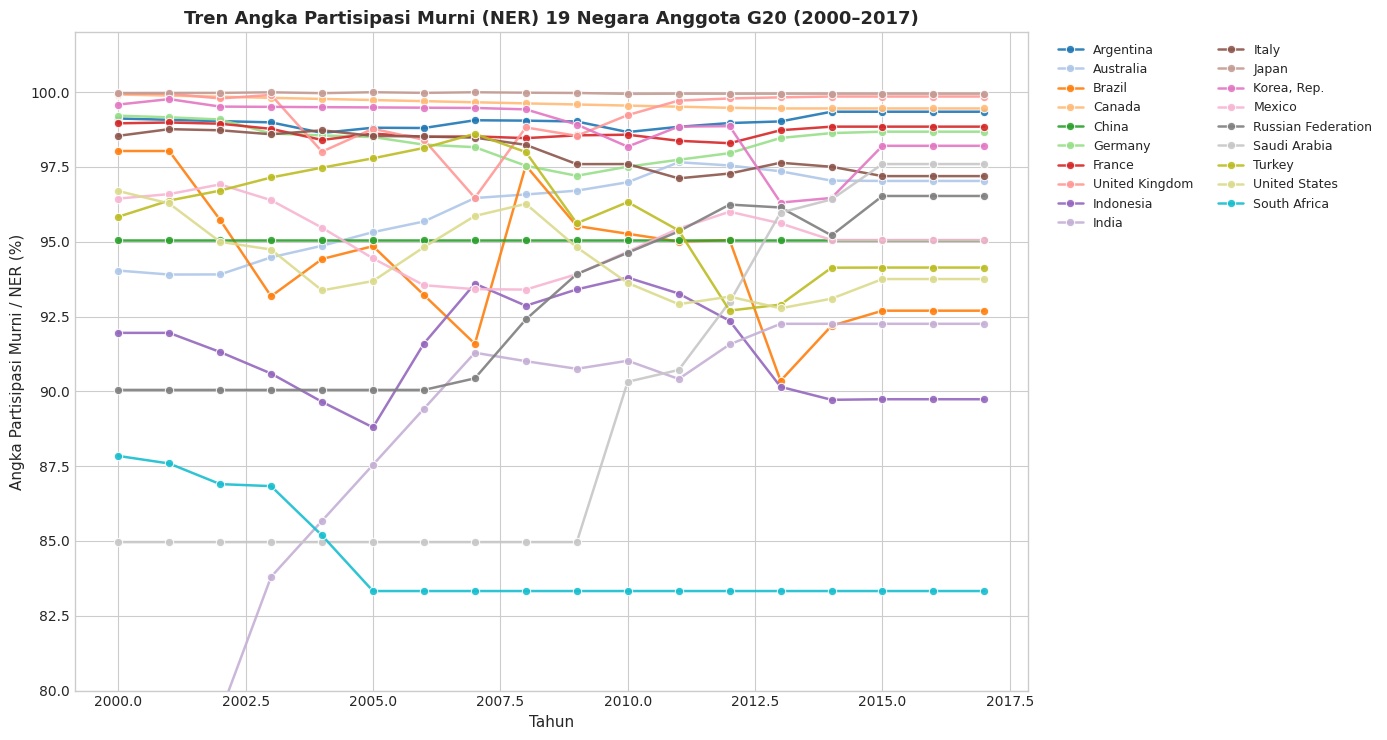

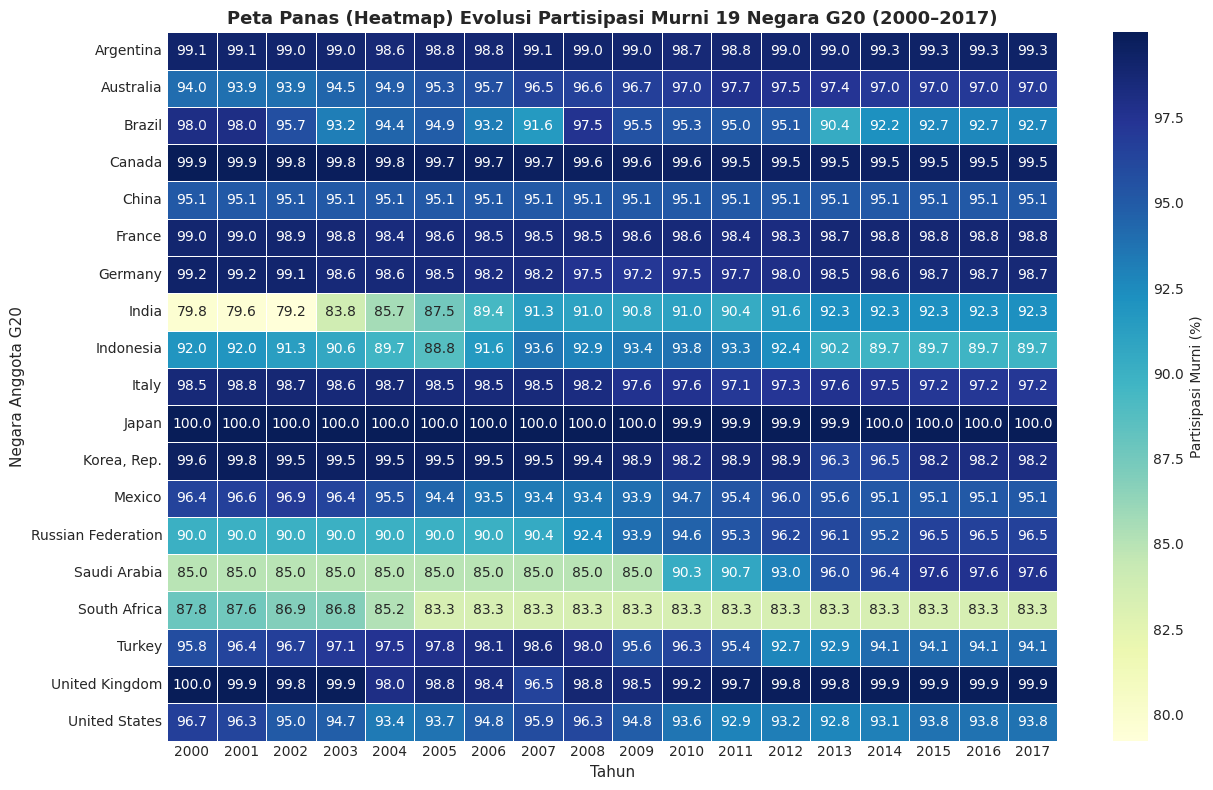

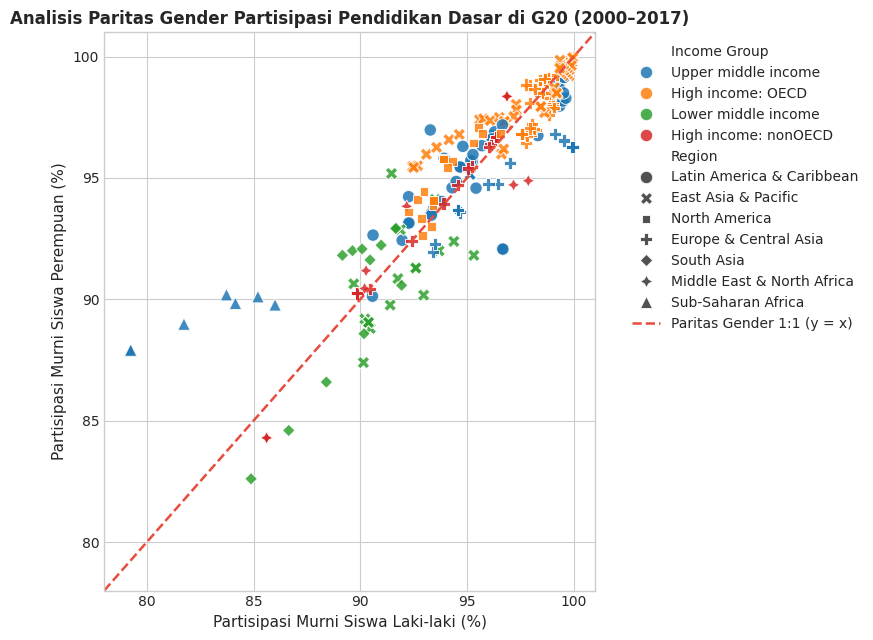

In [13]:
# 7.2 ANALISIS TREN LONGITUDINAL & WAWASAN PENDIDIKAN G20

# 3. Tren Partisipasi Murni (NER) 19 Negara G20 (2000–2017)
plt.figure(figsize=(14, 7.5))
sns.lineplot(
    data=df_clean,
    x='Year',
    y='SE.PRM.NENR',
    hue='Country Name',
    palette='tab20',
    marker='o',
    linewidth=1.8,
    alpha=0.9
)
plt.title('Tren Angka Partisipasi Murni (NER) 19 Negara Anggota G20 (2000–2017)', fontsize=13, fontweight='bold')
plt.xlabel('Tahun', fontsize=11)
plt.ylabel('Angka Partisipasi Murni / NER (%)', fontsize=11)
plt.ylim(80, 102)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('visualisasi_tren_pendidikan_g20.png', dpi=300)
plt.show()

# 4. Heatmap Temporal Partisipasi Murni 19 Negara G20
plt.figure(figsize=(13, 8))
heatmap_matrix = df_clean.pivot(index='Country Name', columns='Year', values='SE.PRM.NENR')
sns.heatmap(
    heatmap_matrix,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': 'Partisipasi Murni (%)'},
    linewidths=0.5
)
plt.title('Peta Panas (Heatmap) Evolusi Partisipasi Murni 19 Negara G20 (2000–2017)', fontsize=13, fontweight='bold')
plt.xlabel('Tahun', fontsize=11)
plt.ylabel('Negara Anggota G20', fontsize=11)
plt.tight_layout()
plt.savefig('temporal_heatmap_g20.png', dpi=300)
plt.show()

# 5. Plot Paritas Gender G20
plt.figure(figsize=(8.5, 6.5))
sns.scatterplot(
    data=df_clean,
    x='SE.PRM.NENR.MA',
    y='SE.PRM.NENR.FE',
    hue='Income Group',
    style='Region',
    s=80,
    alpha=0.85
)
plt.plot([78, 101], [78, 101], color='#e74c3c', linestyle='--', linewidth=1.8, label='Paritas Gender 1:1 (y = x)')
plt.title('Analisis Paritas Gender Partisipasi Pendidikan Dasar di G20 (2000–2017)', fontsize=12, fontweight='bold')
plt.xlabel('Partisipasi Murni Siswa Laki-laki (%)', fontsize=11)
plt.ylabel('Partisipasi Murni Siswa Perempuan (%)', fontsize=11)
plt.xlim(78, 101)
plt.ylim(78, 101)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('gender_parity_analysis.png', dpi=300)
plt.show()